# Demand Forecasting

## Data and Libraries Import

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import os
from pathlib import Path
from dotenv import load_dotenv,find_dotenv

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from statsforecast import StatsForecast
from statsforecast.models import Naive, AutoARIMA, WindowAverage, SeasonalNaive, HistoricAverage

from sqlalchemy import create_engine, text


import warnings
warnings.filterwarnings('ignore')

In [2]:
env_path =Path.cwd()/"github_repo_cloned"/"india-logistics-hub-optimizer"/".env"
load_dotenv(env_path) 

HOST = os.getenv("DB_HOST")
USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
OUTPUT_DIR = os.getenv("OUTPUT_DIR")

In [3]:
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}")


def sql(query, engine = engine):
    with engine.connect() as conn:
        df = pd.read_sql(text(query),conn)
    return df

In [4]:
query = "select * from forecasting_data"

data = sql(query=query,engine=engine)

In [5]:
data.head()

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
0,andaman and nicobar,2018-07,7499.0,194.66,7499.0,194.66
1,andhra pradesh,2018-07,1931596.0,66363.08,1931596.0,66363.08
2,arunachal pradesh,2018-07,19147.0,394.15,19147.0,394.15
3,assam,2018-07,601740.0,17874.21,601740.0,17874.21
4,bihar,2018-07,616137.0,18787.14,616137.0,18787.14


## Initial Data Check

### Structure and Types

In [6]:
data.nunique().reset_index(name = 'unique_counts')

,index,unique_counts
0,state,38
1,date,97
2,bill_volume,3628
3,bill_amount,3651
4,avg_bill_3m,3654
5,avg_amount_3m,3648


In [7]:
print(f"Row Counts: {data.shape[0]}")
print(f"Columns Counts: {data.shape[1]}")

Row Counts: 3664
Columns Counts: 6


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3664 entries, 0 to 3663
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state          3664 non-null   object 
 1   date           3664 non-null   object 
 2   bill_volume    3664 non-null   float64
 3   bill_amount    3664 non-null   float64
 4   avg_bill_3m    3664 non-null   float64
 5   avg_amount_3m  3664 non-null   float64
dtypes: float64(4), object(2)
memory usage: 171.9+ KB


In [9]:
# Fixing the date column to be actual date
data['date']=pd.to_datetime(data['date'])

In [10]:
data.tail()

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
3659,telangana,2026-07-01,8447660.0,211987.55,8048599.67,196357.59
3660,tripura,2026-07-01,109743.0,3155.15,110157.00,3092.29
3661,uttar pradesh,2026-07-01,14754474.0,411616.83,14952457.33,399273.95
3662,uttarakhand,2026-07-01,2506908.0,75000.60,2497027.00,72142.35
3663,west bengal,2026-07-01,8005465.0,217782.38,7918081.00,211972.25


In [11]:
# Renaming columns for easy usage
rename_dict = {
    'bill_volume':'volume',
    'bill_amount':'amount'
}

data.rename(rename_dict,axis=1, inplace=True)

In [12]:
data.head()

,state,date,volume,amount,avg_bill_3m,avg_amount_3m
0,andaman and nicobar,2018-07-01,7499.0,194.66,7499.0,194.66
1,andhra pradesh,2018-07-01,1931596.0,66363.08,1931596.0,66363.08
2,arunachal pradesh,2018-07-01,19147.0,394.15,19147.0,394.15
3,assam,2018-07-01,601740.0,17874.21,601740.0,17874.21
4,bihar,2018-07-01,616137.0,18787.14,616137.0,18787.14


In [13]:
data.isnull().sum().reset_index(name = 'null_values')

,index,null_values
0,state,0
1,date,0
2,volume,0
3,amount,0
4,avg_bill_3m,0
5,avg_amount_3m,0


### Integrity

In [14]:
cols_needed = ['date','volume','amount']
desc = data[cols_needed].describe().round(2).reset_index()
desc

,index,date,volume,amount
0,count,3664,3664.00,3664.00
1,mean,2022-07-09 05:55:17.030567936,2890968.35,82640.38
2,min,2018-07-01 00:00:00,20.00,0.38
3,25%,2020-07-01 00:00:00,63662.50,2670.52
4,50%,2022-07-01 00:00:00,953312.50,33426.55
5,75%,2024-07-01 00:00:00,3884065.50,117355.20
6,max,2026-07-01 00:00:00,27217002.00,851046.04
7,std,NaN,4342989.22,121680.10


In [15]:
# Checking for duplicate data and state combo
data.groupby(['state','date']).size().reset_index(name = 'cnt').query('cnt>1')

,state,date,cnt


In [16]:
min_grouped = data.groupby('state')['date'].min().reset_index(name = 'min_date')
min_grouped[min_grouped['min_date'] != "2018-07-01"]


,state,min_date
18,ladakh,2020-01-01
27,other territory,2018-11-01


In [17]:
max_grouped = data.groupby('state')['date'].max().reset_index(name = 'max_date')
max_grouped[max_grouped['max_date'] != "2026-07-01"]


,state,max_date


In [18]:
row_counts = data.groupby('state').size().reset_index(name = 'row_count')
row_counts['diff'] = 97 - row_counts['row_count']
print("Row Difference in States: ")
row_counts.query('diff !=0')[['state','diff']]


Row Difference in States: 


,state,diff
18,ladakh,18
27,other territory,4


In [19]:
data = data[data['state'] != 'other territory']

### Value Validity

In [20]:
data = data.sort_values(by=['state','date'])
data['amt_per_bill'] = (data['amount']/data['volume'])*100
data['change_pct'] = data.groupby('state')['amt_per_bill'].pct_change()*100
data.head()

,state,date,volume,amount,avg_bill_3m,avg_amount_3m,amt_per_bill,change_pct
0,andaman and nicobar,2018-07-01,7499.0,194.66,7499.00,194.66,2.595813,NaN
36,andaman and nicobar,2018-08-01,8722.0,214.62,8110.50,204.64,2.460674,-5.206023
72,andaman and nicobar,2018-09-01,8415.0,256.96,8212.00,222.08,3.053595,24.095861
108,andaman and nicobar,2018-10-01,8690.0,213.03,8609.00,228.20,2.451438,-19.719589
144,andaman and nicobar,2018-11-01,8087.0,206.80,8397.33,225.60,2.557191,4.313880


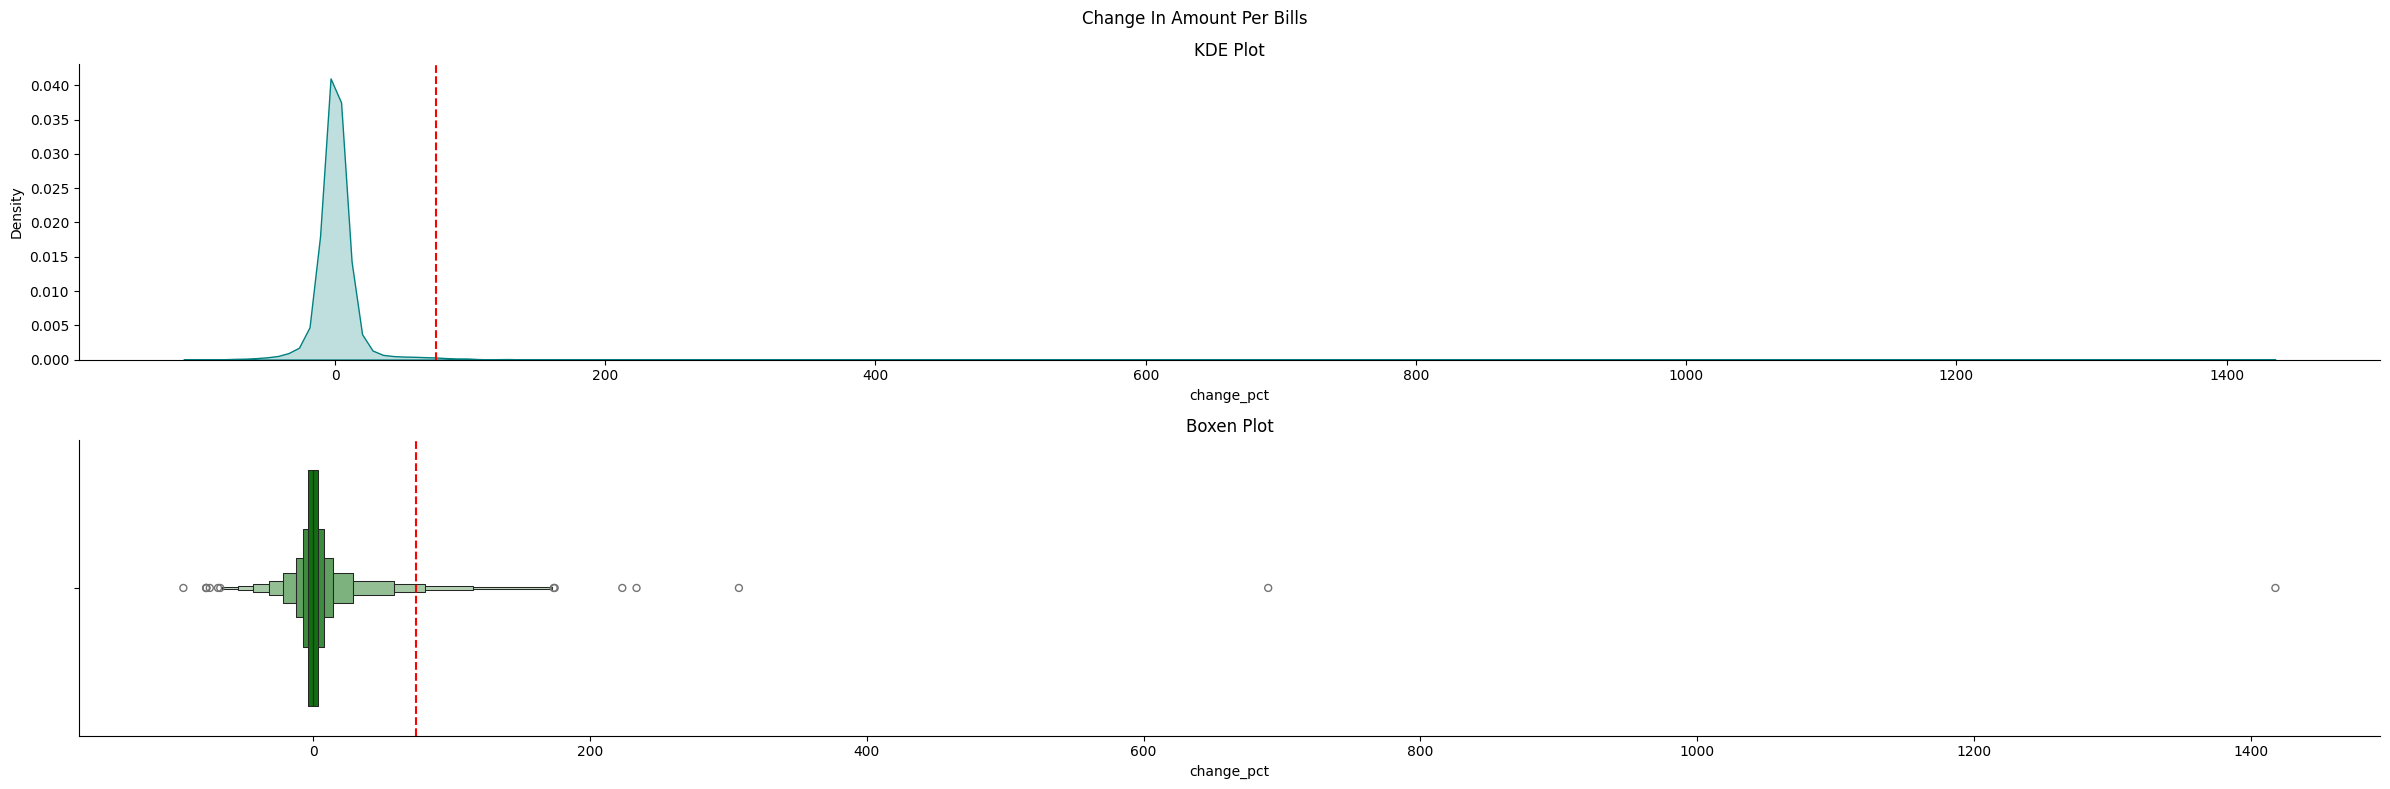

In [21]:
plt.figure(figsize=(24,8))
plt.subplot(2,1,1)
sns.kdeplot(x = 'change_pct',data=data,color='teal',fill=True)
plt.axvline(data['change_pct'].quantile(.99),color='red',linestyle='--')
plt.title("KDE Plot")
plt.subplot(2,1,2)
sns.boxenplot(x = 'change_pct',data=data,color='green')
plt.axvline(data['change_pct'].quantile(.99),color='red',linestyle='--')
plt.title("Boxen Plot")
plt.suptitle("Change In Amount Per Bills")
sns.despine()
plt.tight_layout()
plt.show()

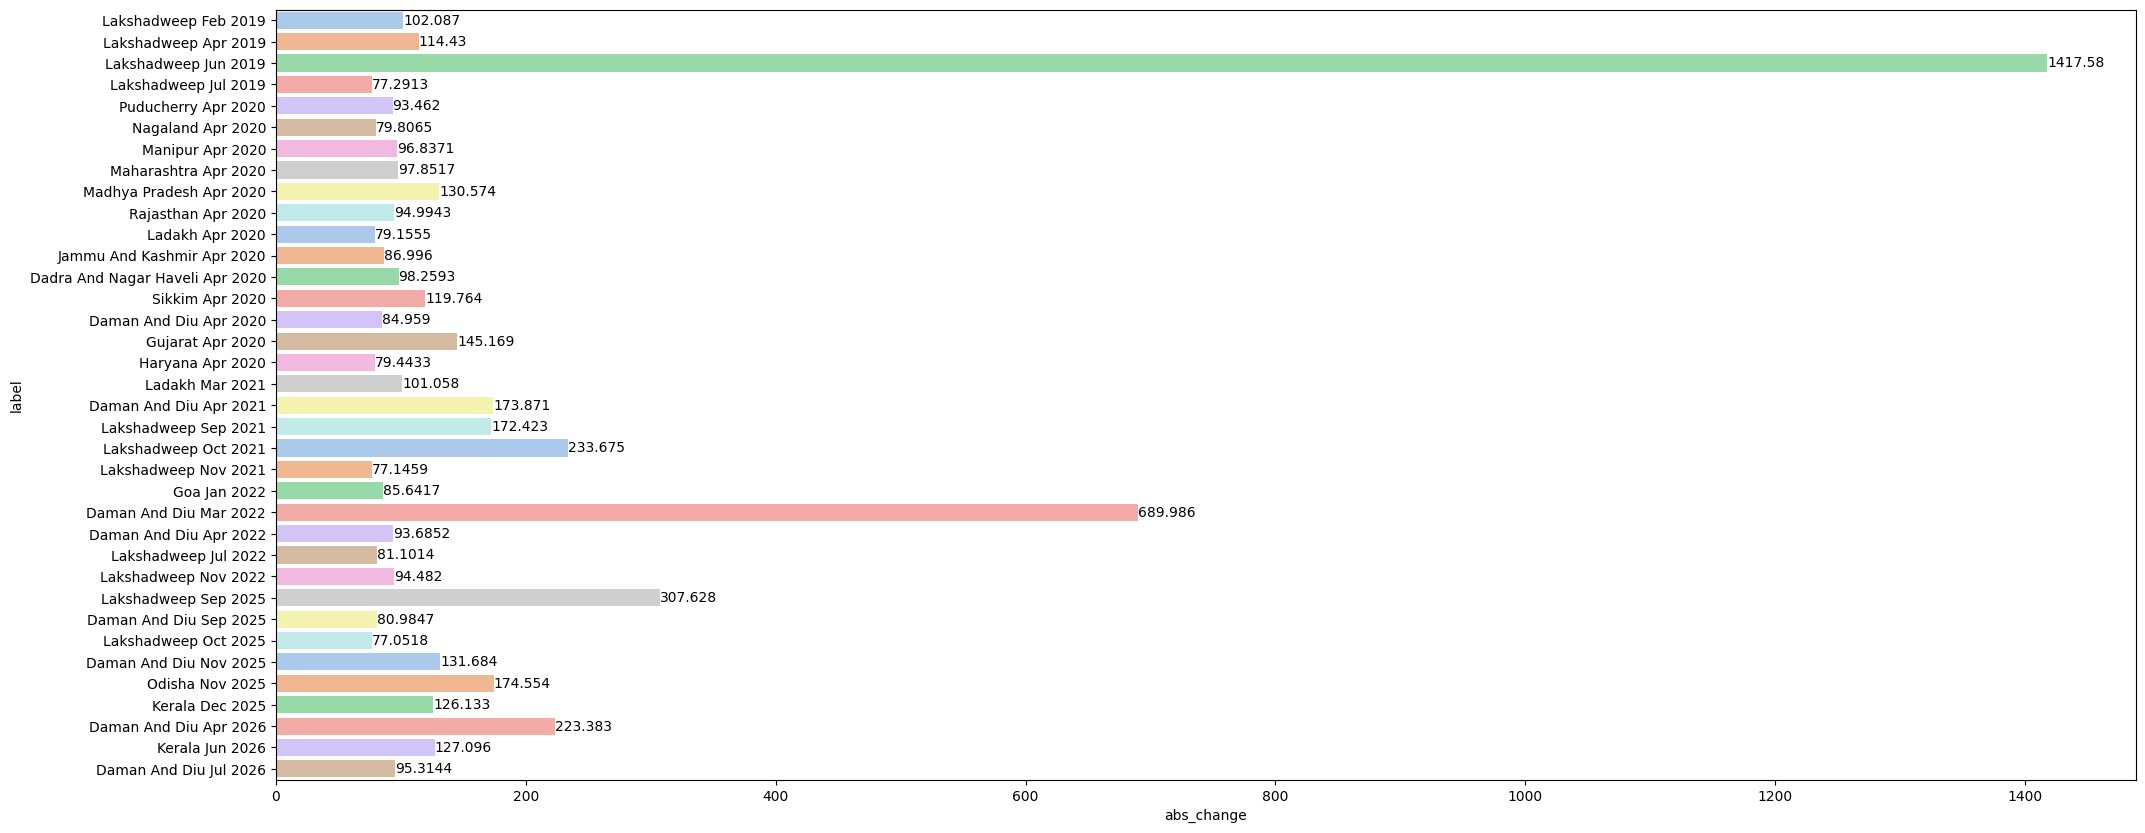

In [22]:
data['abs_change']= data['change_pct'].abs()
anomaly_changes = data[data['abs_change']>data['abs_change'].quantile(.99)].sort_values(by='date',ascending=True)
anomaly_changes['label'] = data['state'].str.title()+ " " + data['date'].dt.strftime('%b %Y')
plt.figure(figsize=(24,10))
ax = sns.barplot(x='abs_change',y='label',data=anomaly_changes,palette='pastel')
for container in ax.containers:
    ax.bar_label(container=container)
plt.show()

In [23]:
anomaly_changes['state'].value_counts().reset_index(name = 'count')

,state,count
0,lakshadweep,11
1,daman and diu,8
2,ladakh,2
3,kerala,2
4,puducherry,1
5,maharashtra,1
6,madhya pradesh,1
7,manipur,1
8,nagaland,1
9,jammu and kashmir,1


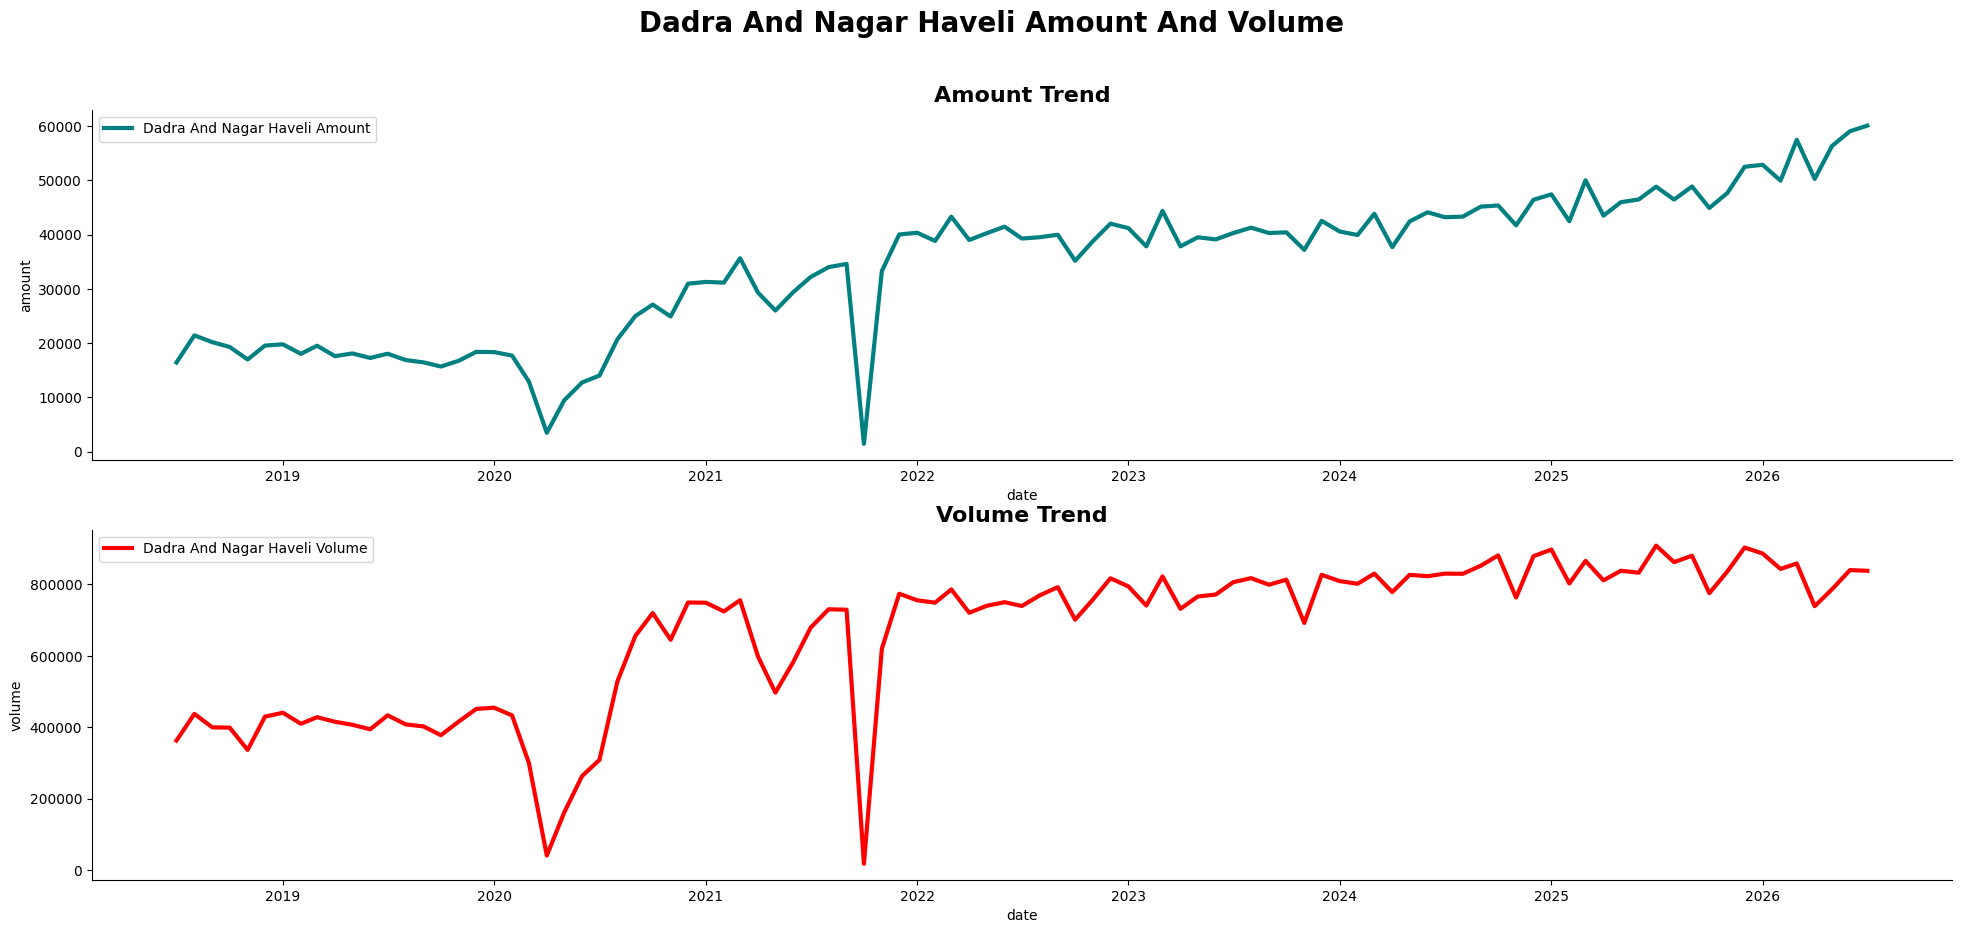

In [24]:
plt.figure(figsize=(24,10))
plt.subplot(2,1,1)
sns.lineplot(x = 'date', y='amount',data=data[data['state'].isin(['dadra and nagar haveli'])],color = 'teal',linewidth = 3, label = 'Dadra And Nagar Haveli Amount')
plt.title("Amount Trend",fontsize = 16,weight = 'bold')
plt.legend()
sns.despine()
plt.subplot(2,1,2)
sns.lineplot(x = 'date', y='volume',data=data[data['state'].isin(['dadra and nagar haveli'])],color = 'red',linewidth = 3, label = 'Dadra And Nagar Haveli Volume')
plt.title("Volume Trend",fontsize = 16,weight = 'bold')
sns.despine()
plt.suptitle("Dadra And Nagar Haveli Amount And Volume",fontsize = 20,weight = 'bold')
plt.show()

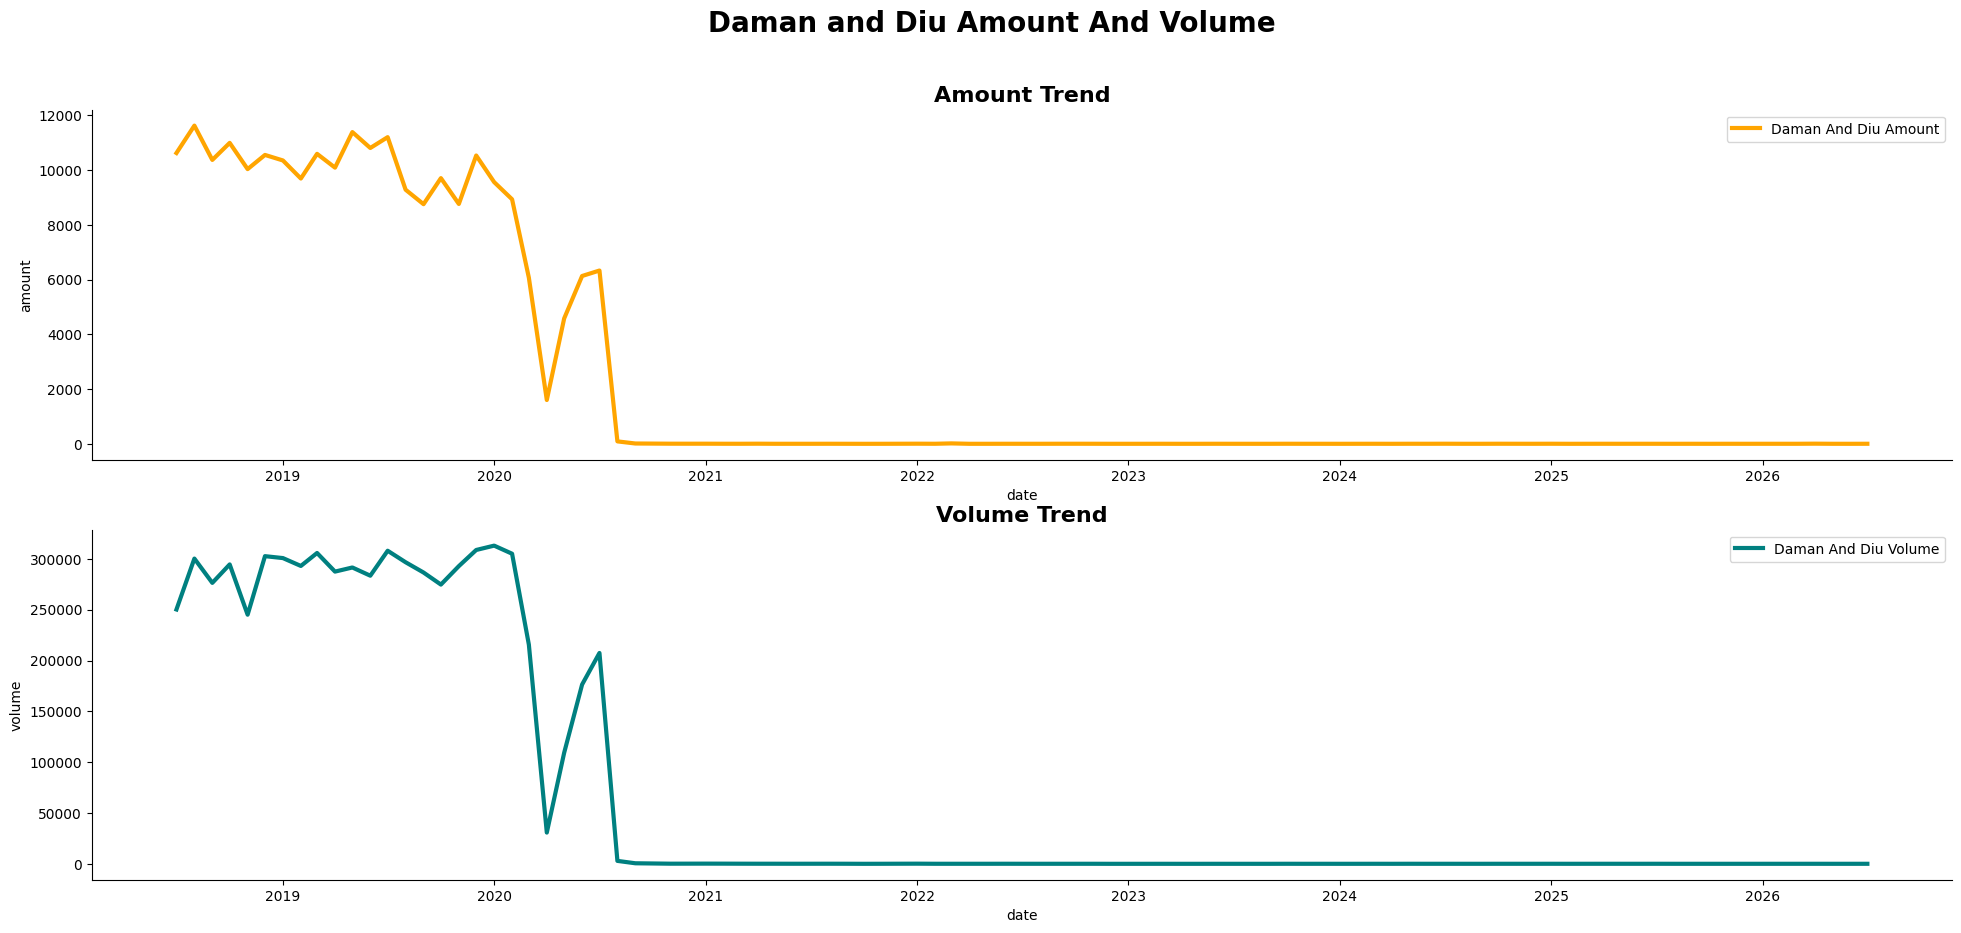

In [25]:
plt.figure(figsize=(24,10))
plt.subplot(2,1,1)
sns.lineplot(x = 'date', y='amount',data=data[data['state'].isin(['daman and diu'])],color = 'orange',linewidth = 3, label = 'Daman And Diu Amount')
plt.title("Amount Trend",fontsize = 16,weight = 'bold')
plt.legend()
sns.despine()
plt.subplot(2,1,2)
sns.lineplot(x = 'date', y='volume',data=data[data['state'].isin(['daman and diu'])],color = 'teal',linewidth = 3, label = 'Daman And Diu Volume')
plt.title("Volume Trend",fontsize = 16,weight = 'bold')
sns.despine()
plt.suptitle("Daman and Diu Amount And Volume",fontsize = 20,weight = 'bold')
plt.show()

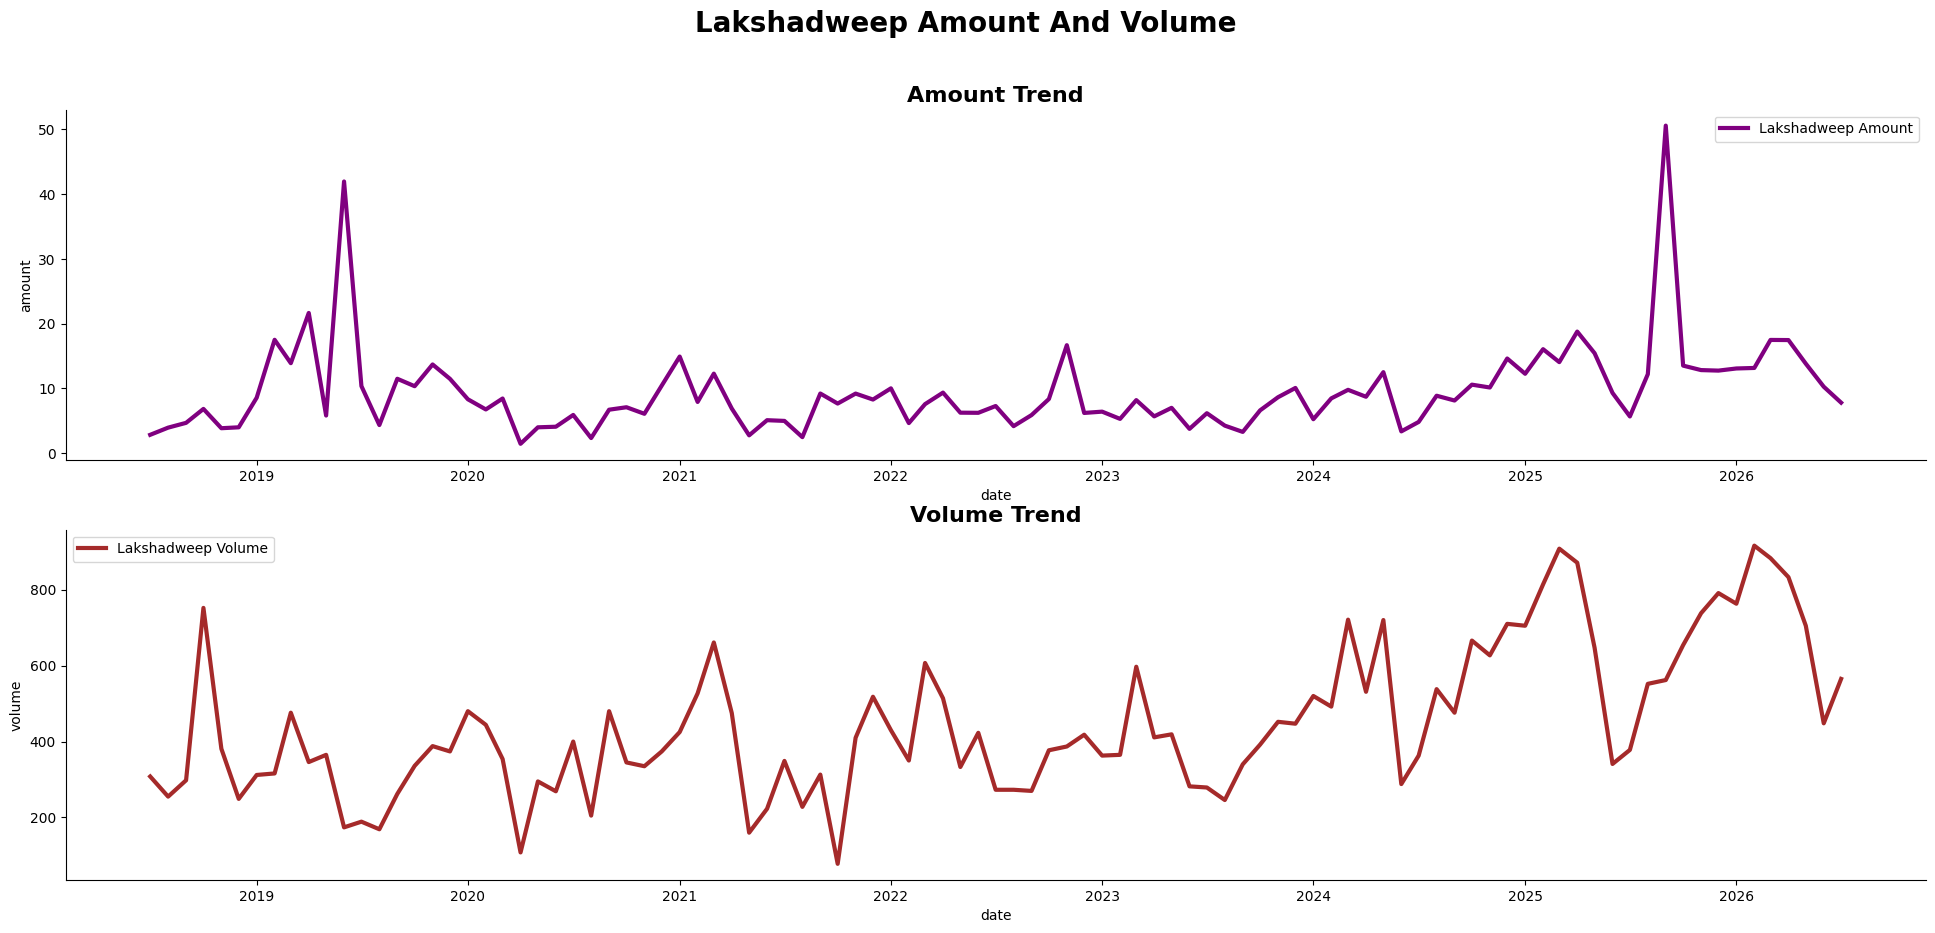

In [26]:
plt.figure(figsize=(24,10))
plt.subplot(2,1,1)
sns.lineplot(x = 'date', y='amount',data=data[data['state'].isin(['lakshadweep'])],color = 'purple',linewidth = 3, label = 'Lakshadweep Amount')
plt.title("Amount Trend",fontsize = 16,weight = 'bold')
plt.legend()
sns.despine()
plt.subplot(2,1,2)
sns.lineplot(x = 'date', y='volume',data=data[data['state'].isin(['lakshadweep'])],color = 'brown',linewidth = 3, label = 'Lakshadweep Volume')
plt.title("Volume Trend",fontsize = 16,weight = 'bold')
sns.despine()
plt.suptitle("Lakshadweep Amount And Volume",fontsize = 20,weight = 'bold')
plt.show()

In [27]:
# Step 1: give both the same name
data['state'] = data['state'].replace({
    'dadra and nagar haveli': 'dnh and dd',
    'daman and diu': 'dnh and dd'
})

# Step 2: add up the rows that now share state + date
cols = ['volume', 'amount', 'avg_bill_3m', 'avg_amount_3m']
data = data.groupby(['state', 'date'], as_index=False)[cols].sum()

In [28]:
data.head()

,state,date,volume,amount,avg_bill_3m,avg_amount_3m
0,andaman and nicobar,2018-07-01,7499.0,194.66,7499.00,194.66
1,andaman and nicobar,2018-08-01,8722.0,214.62,8110.50,204.64
2,andaman and nicobar,2018-09-01,8415.0,256.96,8212.00,222.08
3,andaman and nicobar,2018-10-01,8690.0,213.03,8609.00,228.20
4,andaman and nicobar,2018-11-01,8087.0,206.80,8397.33,225.60


## EDA

In [31]:
def plot_bill_trend(column, title="", filename=None):
    plt.figure(figsize=(25,8))
    ax = sns.lineplot(x='date', y=column, data=data, color='#1B7A72')
    ax.set_title(title, weight='bold', fontsize=20)
    plt.xlabel("Date", fontsize=10, weight='bold')
    plt.ylabel("Bill Volume", fontsize=15, weight='bold')

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', which='major', labelsize=11, pad=20)
    ax.tick_params(axis='x', which='minor', labelsize=8, colors='black')

    lockdown_start = pd.Timestamp('2020-03-01')
    lockdown_end = pd.Timestamp('2020-06-30')
    ax.axvspan(lockdown_start, lockdown_end, color='red', alpha=0.12, zorder=0)
    ax.text(lockdown_start + (lockdown_end - lockdown_start)/2, ax.get_ylim()[1]*0.95,
            'COVID-19\nLockdown', ha='center', va='top', fontsize=9, color='darkred', weight='bold')

    sns.despine(left=True, bottom=True)
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()

    filename = filename or f"{column}_trend.png"
    plt.savefig(f"{OUTPUT_DIR}/{filename}", dpi=150, bbox_inches='tight')
    plt.show()

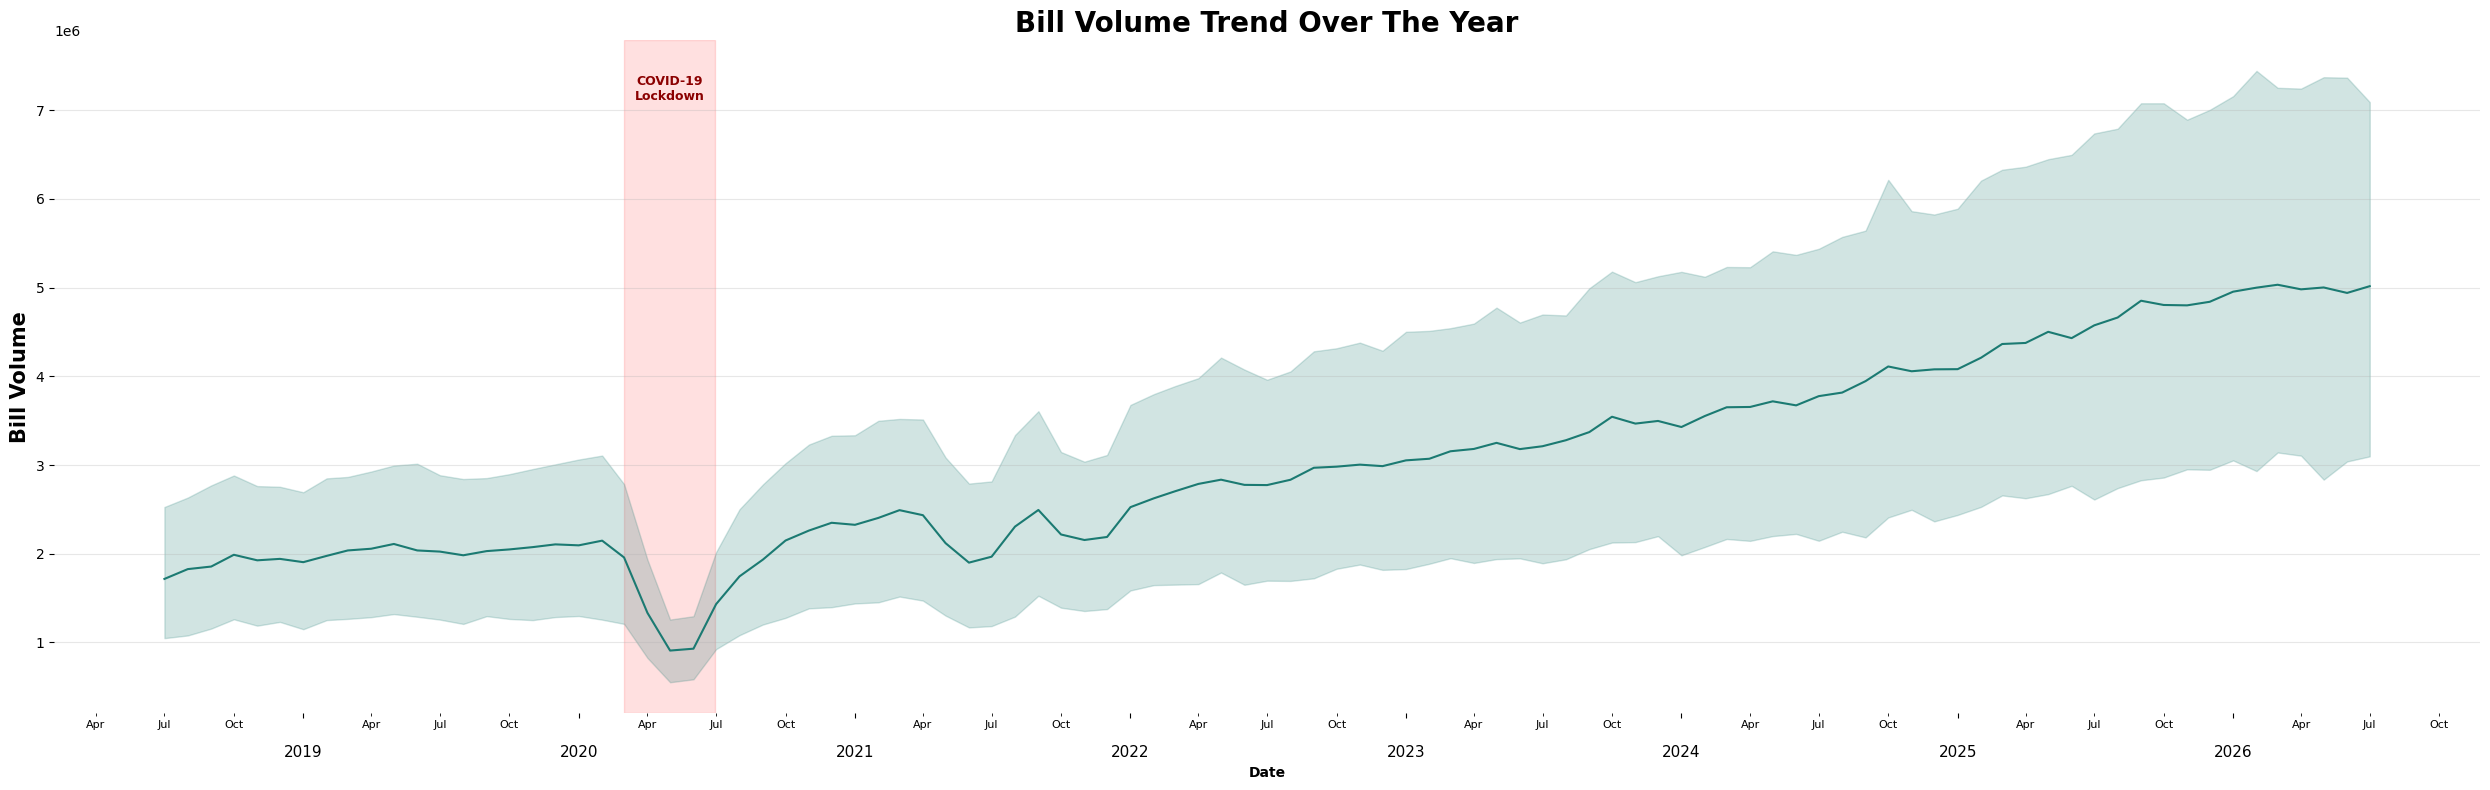

In [32]:
plot_bill_trend('avg_bill_3m',title="Bill Volume Trend Over The Year",filename="bill_volume_trend.png")

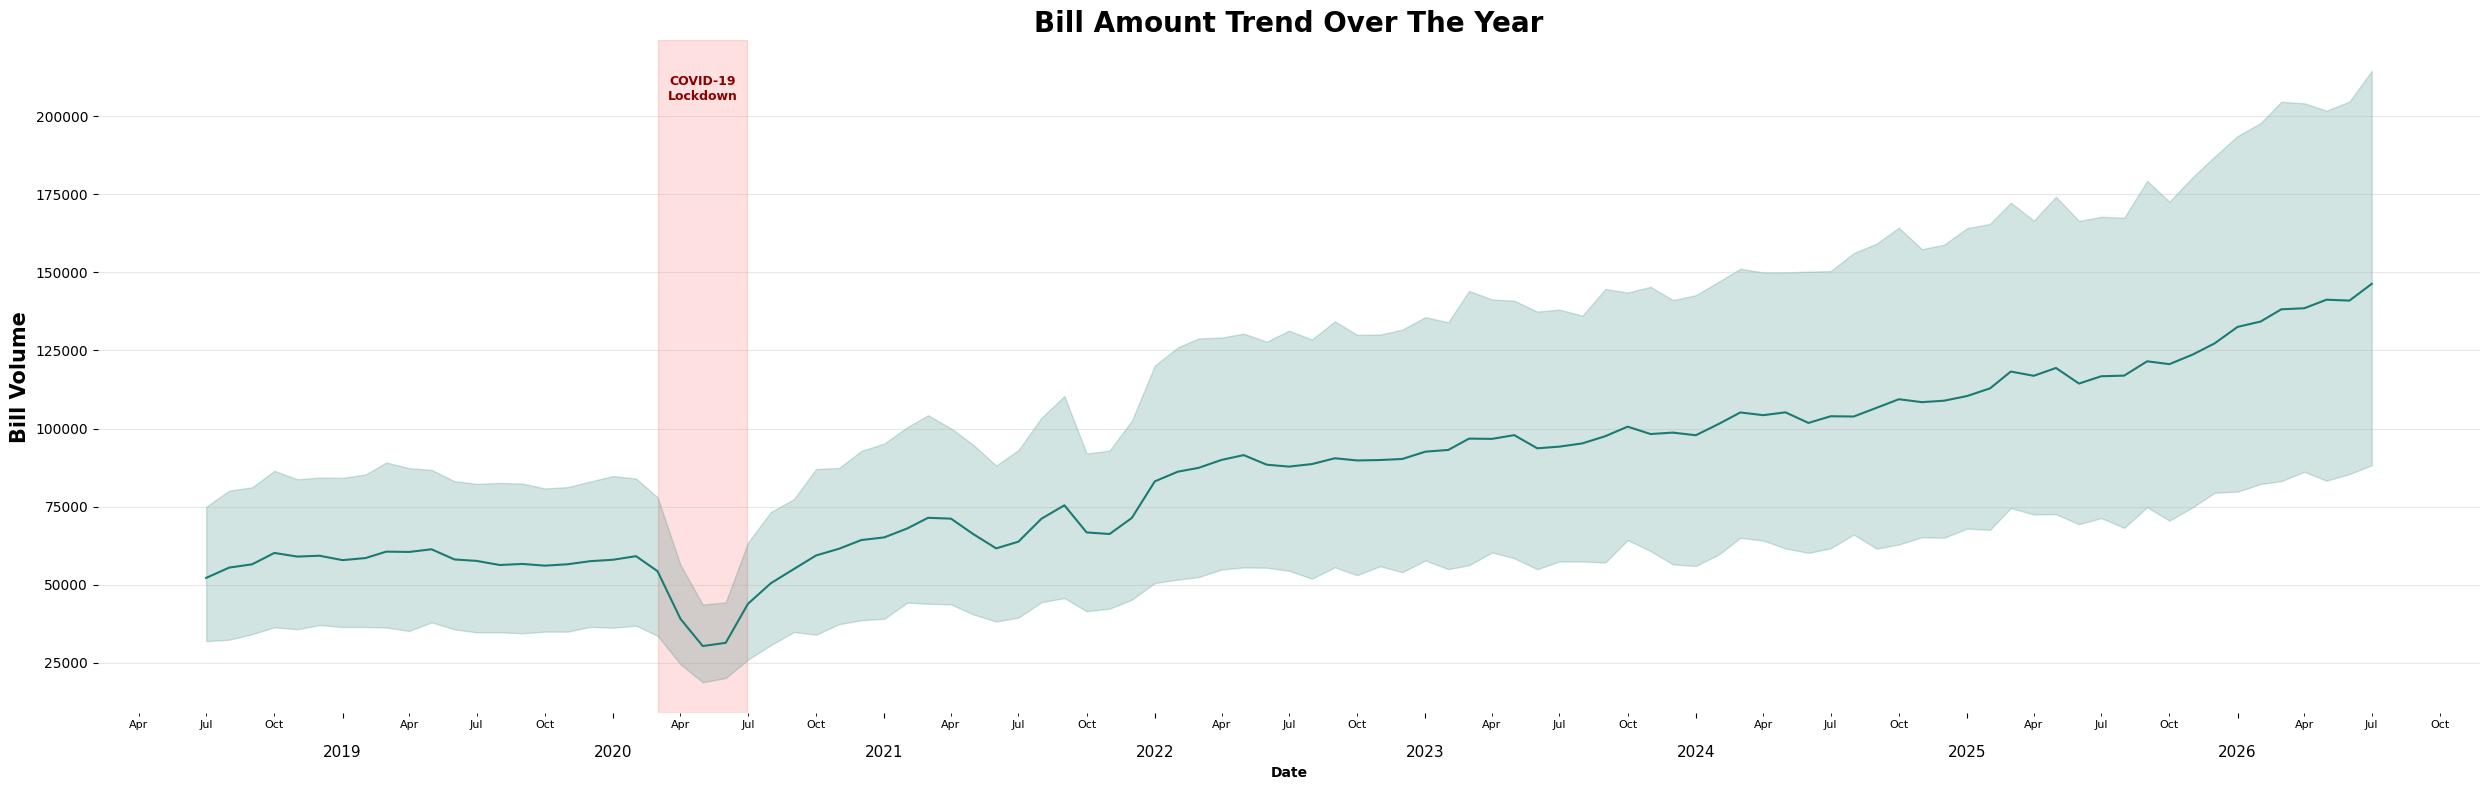

In [33]:
plot_bill_trend('avg_amount_3m',title="Bill Amount Trend Over The Year",filename="bill_amount_trend.png")

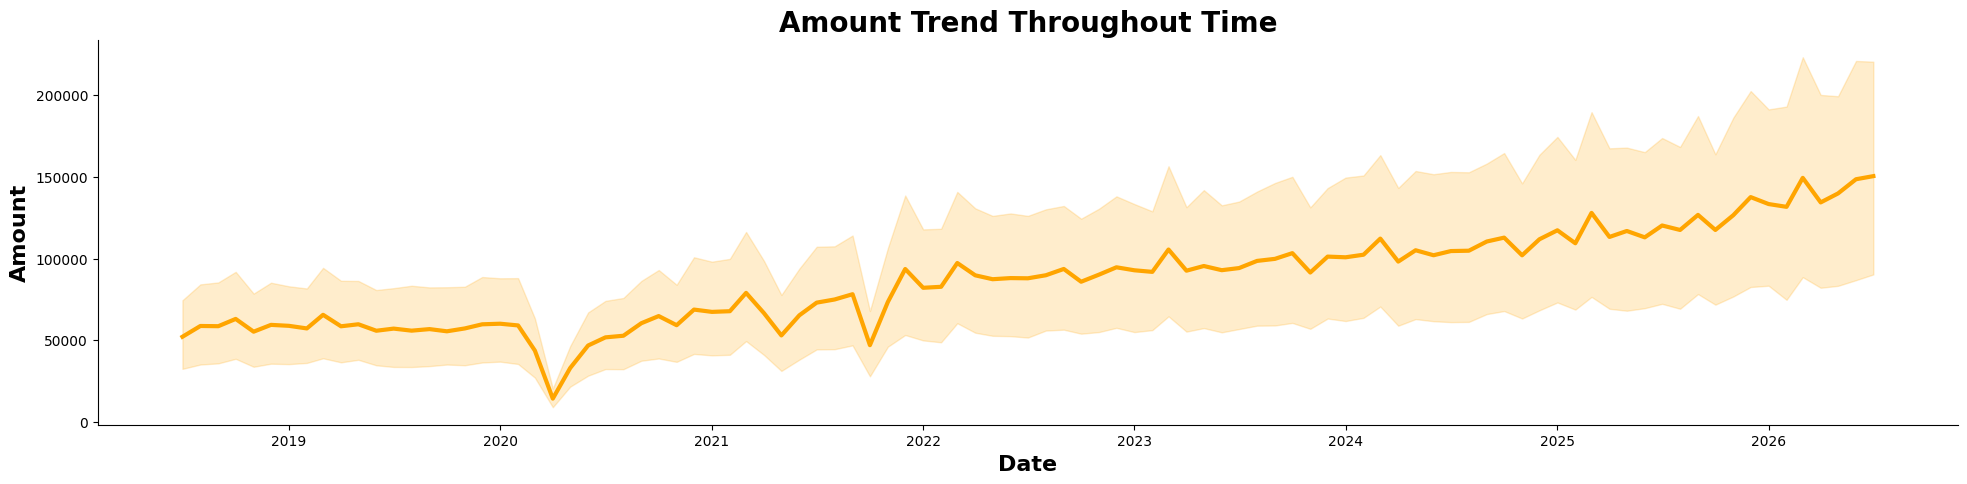

In [39]:
plt.figure(figsize=(24,5))
sns.lineplot(x = 'date',y='amount',data=data,linewidth=3,color='orange')
plt.title('Amount Trend Throughout Time',fontsize= 20,weight = 'bold')
plt.xlabel("Date",fontsize=16,weight = 'bold')
plt.ylabel("Amount",fontsize=16,weight = 'bold')
sns.despine()
plt.show()

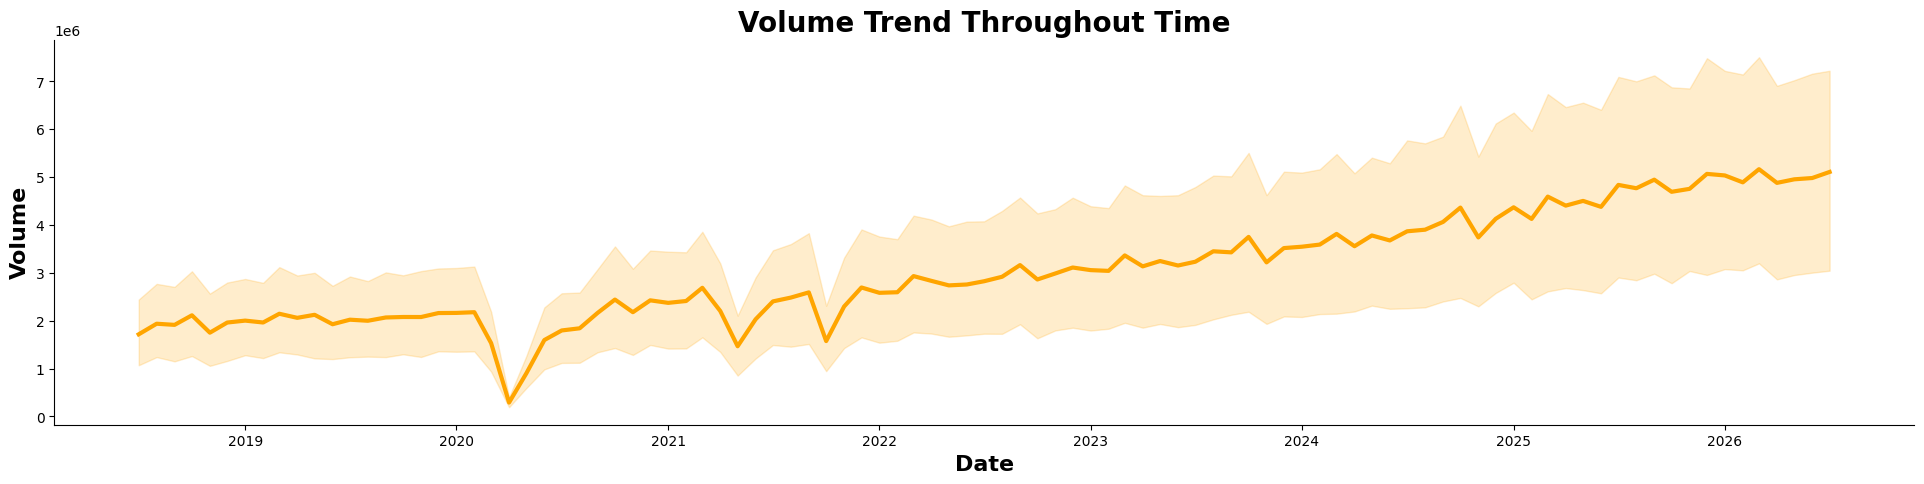

In [40]:
plt.figure(figsize=(24,5))
sns.lineplot(x = 'date',y='volume',data=data,linewidth=3,color='orange')
plt.title('Volume Trend Throughout Time',fontsize= 20,weight = 'bold')
plt.xlabel("Date",fontsize=16,weight = 'bold')
plt.ylabel("Volume",fontsize=16,weight = 'bold')
sns.despine()
plt.show()

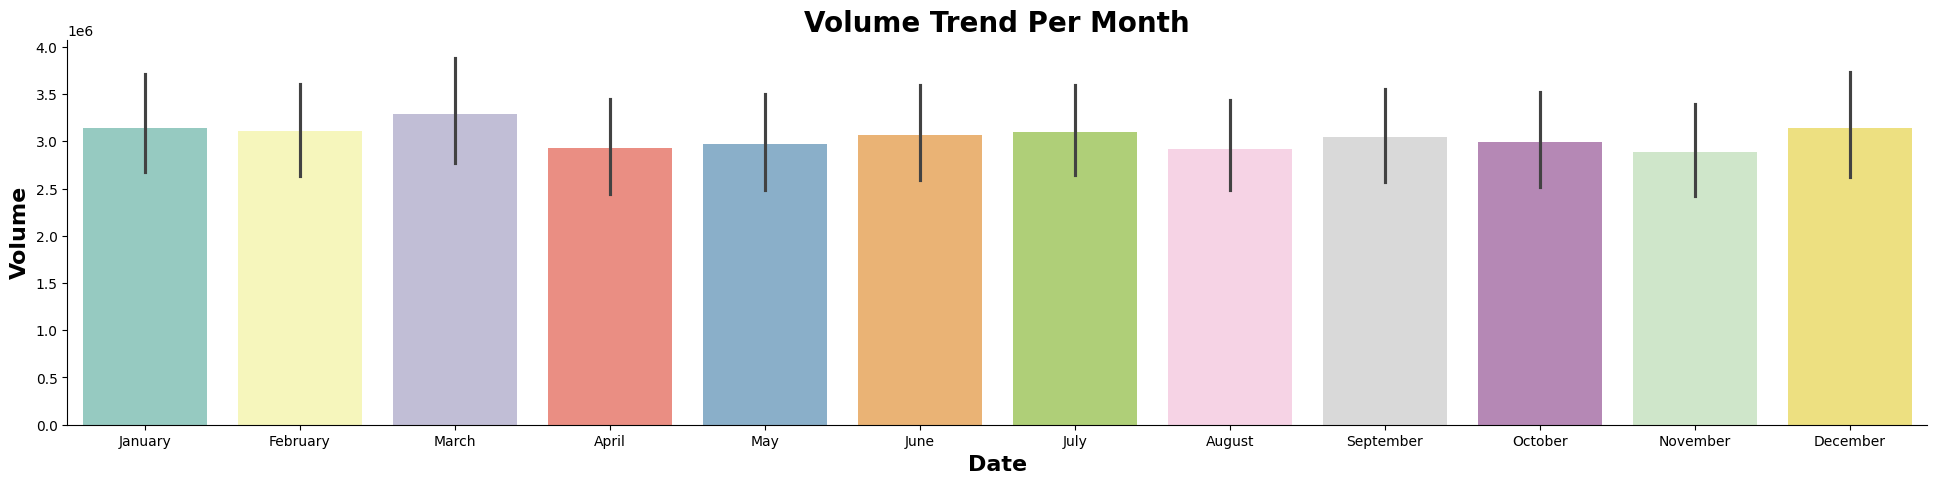

In [54]:
plt.figure(figsize=(24,5))
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sns.barplot(x = data['date'].dt.month_name(),y='volume',data=data,palette='Set3',order=month_order)
plt.title('Volume Trend Per Month',fontsize= 20,weight = 'bold')
plt.xlabel("Date",fontsize=16,weight = 'bold')
plt.ylabel("Volume",fontsize=16,weight = 'bold')
sns.despine()
plt.show()

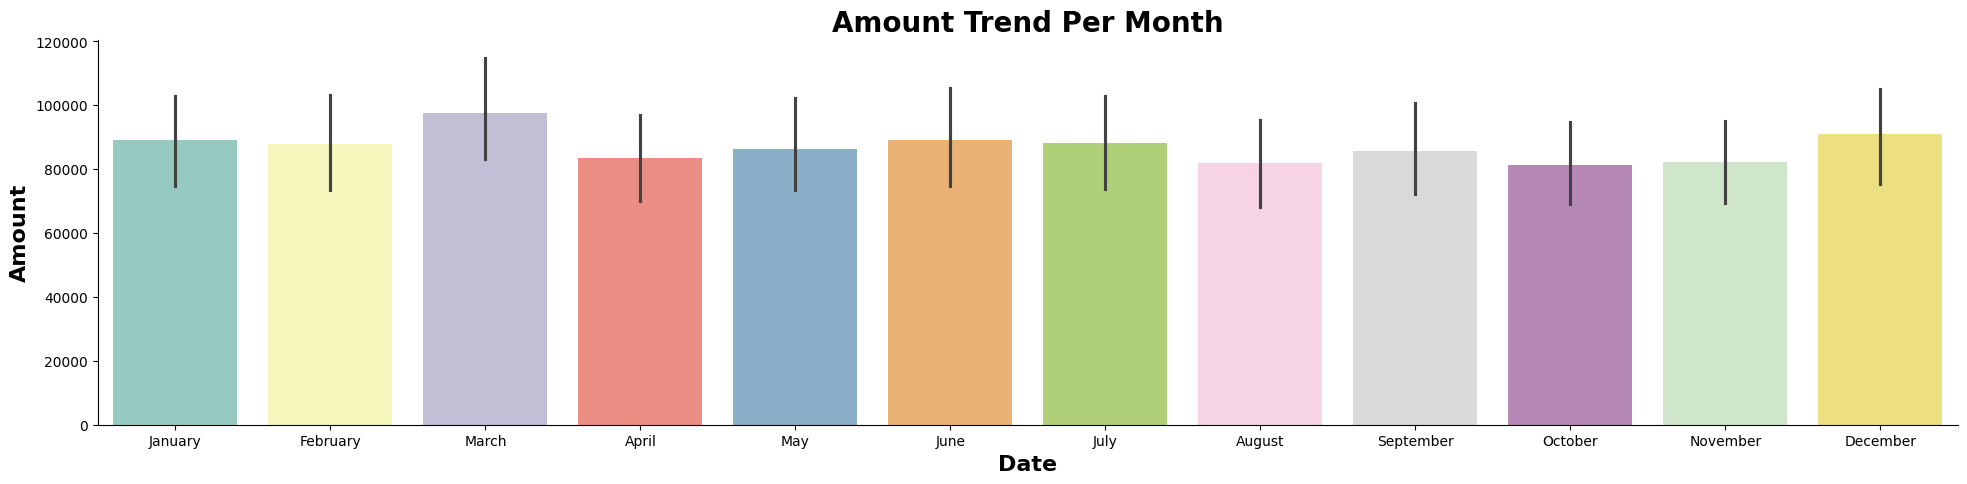

In [55]:
plt.figure(figsize=(24,5))
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sns.barplot(x = data['date'].dt.month_name(),y='amount',data=data,palette='Set3',order=month_order)
plt.title('Amount Trend Per Month',fontsize= 20,weight = 'bold')
plt.xlabel("Date",fontsize=16,weight = 'bold')
plt.ylabel("Amount",fontsize=16,weight = 'bold')
sns.despine()
plt.show()